---
<h1 style="text-align:center; font-weight:900">Práctica LSTM</h1>
<h4 style="text-align:center; font-weight:500">Sofía Maldonado García</h4>
<h4 style="text-align:center; font-weight:500">10/05/2026</h4>

---

In [96]:
# Librerias
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

import plotly.graph_objects as go
import yfinance as yf

In [97]:
# Cargando datos
TICKER = "SOFI" # Compañía de servicios financieros
xom = yf.Ticker(TICKER)
df = xom.history(start='2025-11-01', end='2026-05-08') # El 9 y el 10 es fin de semana


In [98]:
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-11-03 00:00:00-05:00,29.660000,31.219999,29.330000,30.629999,90431700,0.0,0.0
2025-11-04 00:00:00-05:00,29.295000,30.790001,28.690001,29.370001,71481000,0.0,0.0
2025-11-05 00:00:00-05:00,29.520000,30.370001,29.010000,30.070000,57853300,0.0,0.0
2025-11-06 00:00:00-05:00,30.125000,30.858999,27.129999,27.160000,88016900,0.0,0.0
2025-11-07 00:00:00-05:00,26.525000,28.240000,25.660000,28.209999,78769400,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-01 00:00:00-04:00,16.235001,16.795000,15.875000,16.430000,79288500,0.0,0.0
2026-05-04 00:00:00-04:00,16.469999,16.780001,16.129999,16.200001,66311900,0.0,0.0
2026-05-05 00:00:00-04:00,16.170000,16.309999,15.940000,16.020000,53952900,0.0,0.0


In [99]:
serie = np.array(df['Close'])
serie

array([30.62999916, 29.37000084, 30.06999969, 27.15999985, 28.20999908,
       30.54000092, 30.95000076, 32.20999908, 28.38999939, 27.81999969,
       27.04000092, 26.23999977, 26.71999931, 24.90999985, 25.19000053,
       27.39999962, 28.32999992, 28.48999977, 29.71999931, 29.03000069,
       29.51000023, 29.06999969, 29.60000038, 27.78000069, 27.61000061,
       26.82999992, 27.09000015, 27.06999969, 27.28000069, 25.81999969,
       26.57999992, 25.27000046, 26.29000092, 27.23999977, 27.35000038,
       27.19000053, 27.47999954, 27.06999969, 26.81999969, 26.55999947,
       26.18000031, 27.45999908, 29.28000069, 26.97999954, 27.        ,
       27.71999931, 27.39999962, 26.60000038, 27.13999939, 26.67000008,
       26.44000053, 26.12999916, 25.48999977, 25.63999939, 26.09000015,
       25.85000038, 25.79999924, 25.45999908, 24.60000038, 24.36000061,
       22.80999947, 22.07999992, 21.76000023, 20.75      , 19.45999908,
       20.86000061, 21.35000038, 21.18000031, 20.54999924, 19.29

In [100]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=df.index, y=serie, mode='lines', name='SOFI')
)
fig.update_layout(title='SOFI')

In [101]:
def crear_ventanas(datos, window_size):
    X = []
    y = []
    for i in range(len(datos) - window_size):
        ventana = datos[i : i + window_size]   # valores t, t+1, ..., t+window_size-1
        objetivo = datos[i + window_size]      # valor siguiente: t+window_size
        X.append(ventana)
        y.append(objetivo)
    return np.array(X), np.array(y)

In [102]:
window_size = 10
porcentaje_train = 0.8

n_train = int(len(serie) * porcentaje_train)

serie_train = serie[:n_train]      # solo el pasado
serie_test  = serie[n_train:]      # el futuro

In [103]:
X_train, y_train = crear_ventanas(serie_train, window_size)
X_test,  y_test  = crear_ventanas(serie_test,  window_size)

In [104]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],  X_test.shape[1],  1))

In [105]:
model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(units=10, activation="relu", recurrent_activation='sigmoid'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Si quisieras agregar capas, es necesario agregar return_sequences
# model.add(LSTM(units=16, return_sequences=True, input_shape=(24, 1)))
# model.add(LSTM(units=8)) # La última capa no retorna secuencias

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
hist = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/25


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - loss: 269.2457 - val_loss: 115.6710
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 254.7463 - val_loss: 97.8010
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 243.4708 - val_loss: 64.0303
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 202.4675 - val_loss: 1.7687
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 115.1141 - val_loss: 384.3731
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 98.4080 - val_loss: 62.9371
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 63.8008 - val_loss: 15.4845
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 30.8461 - val_loss: 31.9952
Epoch 9/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.2746 - val_loss: 36.8136
Epoch 10/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19.2078 - val_loss: 11.7761
Epoch 11/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 14.6520 - val_loss: 7.1628
Epoch 12/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.1120 - 

In [107]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


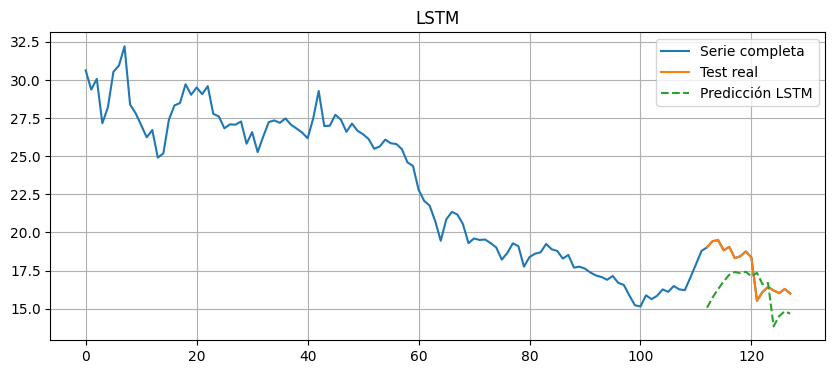

In [108]:
plt.figure(figsize=(10,4))
t = np.arange(len(serie))

plt.plot(t, serie, label='Serie completa')
plt.plot(
    np.arange(n_train + window_size, n_train + window_size + len(y_test)),
    y_test,
    label='Test real'
)
plt.plot(
    np.arange(n_train + window_size, n_train + window_size + len(y_pred)),
    y_pred.flatten(),
    '--',
    label='Predicción LSTM'
)

plt.title("LSTM")
plt.legend()
plt.grid(True)
plt.show()